In [2]:
import ROOT

import genie_loader
from importlib import reload
reload(genie_loader)
from genie_loader import *

In [3]:
det_width=39 #m
det_height=13.8 #m
cut_extend=1 #m

det_half_width = 19.5

In [4]:
ls /project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10

genie_output_NHLLHCBtoνμ/   genie_output_NHLLHCνe/  merged/
genie_output_NHLLHCHardνμ/  genie_output_NHLLHCνμ/


In [5]:
GENIE_OUTPUT_DIR="/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10"
neutrino_sims =["NHLLHCBtoνμAtEachEnergyGeV",
        "NHLLHCHardantiνμAtEachEnergyGeV",
        "NHLLHCHardνμAtEachEnergyGeV",
        "NHLLHCνeAtEachEnergyGeV",
        "NHLLHCνμAtEachEnergyGeV",]


filename = f"{GENIE_OUTPUT_DIR}/genie_output_{neutrino_sims[4].split('AtEachEnergyGeV')[0]}/gntp.1.gtrac.root"

In [27]:

tfile=ROOT.TFile(filename)
tree_name = tfile.GetListOfKeys()[0].GetName()
Tree = tfile.Get(tree_name)
entries = Tree.GetEntries()
branches = [Tree.GetListOfBranches()[i].GetName() for i in range(len(Tree.GetListOfBranches()))]
tfile.ls()
print(entries, branches)

28094 ['EvtFlags', 'EvtCode', 'EvtNum', 'EvtXSec', 'EvtDXSec', 'EvtKPS', 'EvtWght', 'EvtProb', 'EvtVtx', 'StdHepN', 'StdHepPdg', 'StdHepStatus', 'StdHepRescat', 'StdHepX4', 'StdHepP4', 'StdHepPolz', 'StdHepFd', 'StdHepLd', 'StdHepFm', 'StdHepLm']
TFile**		/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10/genie_output_NHLLHCνμ/gntp.1.gtrac.root	
 TFile*		/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10/genie_output_NHLLHCνμ/gntp.1.gtrac.root	
  OBJ: TTree	gRooTracker	GENIE event tree rootracker format : 0 at: 0x5650f0f588e0
  KEY: TTree	gRooTracker;1	GENIE event tree rootracker format


In [28]:
vertices=[]
for i in tqdm(range(entries)):
    Tree.GetEntry(i)    
    vertices.append(list(Tree.EvtVtx))
vertices=np.array(vertices)

100%|██████████| 28094/28094 [00:00<00:00, 66456.51it/s]


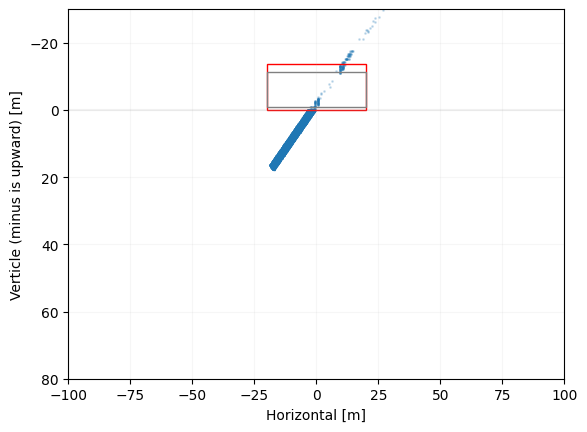

In [32]:
plt.scatter(-vertices[:,0], vertices[:,2], s=1, alpha=0.2)
plt.gca().add_patch(patch.Rectangle((-20,-det_height), 40,det_height, edgecolor='r', facecolor='none'))
plt.gca().add_patch(patch.Rectangle((-20,-det_height+2.4), 40,det_height-3.2, edgecolor='grey', facecolor='none'))
plt.xlim(-100,100)
plt.ylim(-30,80)
plt.gca().invert_yaxis()
plt.axhline(0,color="grey", alpha=0.1)
plt.xlabel("Horizontal [m]")
plt.ylabel("Verticle (minus is upward) [m]")
plt.grid(alpha=0.1)
# plt.axhline(-85.47)

# Select events in the red box and merged to a ROOT file

In [7]:
GENIE_OUTPUT_DIR="/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10"
neutrino_sims =["NHLLHCBtoνμAtEachEnergyGeV",
                "NHLLHCHardνμAtEachEnergyGeV",
                "NHLLHCνeAtEachEnergyGeV",
                "NHLLHCνμAtEachEnergyGeV",]




In [1]:
import simhelper.root as iroot

Welcome to JupyROOT 6.28/10


In [23]:

def process_run(i_run):
    filename_output = f"{GENIE_OUTPUT_DIR}/merged/run_{i_run}_source.root"
    
    #-----------------------------
    # setup output file
    if not os.path.exists(os.path.dirname(filename_output)):
        Path(os.path.dirname(filename_output)).mkdir( parents=True, exist_ok=True )
    tree_writer = iroot.tfile_writer("data", filename_output)
    tree_writer.define_branch("Gen_pdgID", 'vector<double>')    
    tree_writer.define_branch("Gen_x", 'vector<float>')    
    tree_writer.define_branch("Gen_y", 'vector<float>')    
    tree_writer.define_branch("Gen_z", 'vector<float>')    
    tree_writer.define_branch("Gen_t", 'vector<float>')    
    tree_writer.define_branch("Gen_px", 'vector<float>')    
    tree_writer.define_branch("Gen_py", 'vector<float>')    
    tree_writer.define_branch("Gen_pz", 'vector<float>')       
    
    #-----------------------------
    # Loop all simulations in a run
    vertex_selected={}
    for isim in range(len(neutrino_sims)):
        filename = f"{GENIE_OUTPUT_DIR}/genie_output_{neutrino_sims[isim].split('AtEachEnergyGeV')[0]}/gntp.{i_run}.gtrac.root"
        tfile=ROOT.TFile(filename)
        tree_name = tfile.GetListOfKeys()[0].GetName()
        Tree = tfile.Get(tree_name)
        entries = Tree.GetEntries()
        branches = [Tree.GetListOfBranches()[i].GetName() for i in range(len(Tree.GetListOfBranches()))]
        # tfile.ls()
        # print(entries, branches)
    
    
        # Loop all entries
        for i in range(entries):
            Tree.GetEntry(i)   
        
            # Get the vertex location
            vertex=list(Tree.EvtVtx) # (x, y, z, t) of vertex (in SI)
            x,y,z,t = vertex
        
            # Only select those within the detector volume plus a little edge
            if (abs(x)<det_width/2+cut_extend)  &  (abs(y)<det_width/2+cut_extend)  & (-z>-cut_extend) & (-z<det_height+cut_extend):
                # Only read the final state particles in this event
                p4s, pdgs = get_final(Tree)           
                # Get event info
                evtcode=str(Tree.EvtCode).split(";") # Example: 'nu:14;tgt:1000080160;N:2112;proc:Weak[CC],QES;'
                parent_pdg=int(evtcode[0].split(":")[1])
        
                # add back the detector offset
                # xx,yy,zz=y*1000, (-z+85.47)*1000, (x+90)*1000 # Convert to CMS coordinate (wrong)
                xx,yy,zz=-x*1000, y*1000, -z*1000
                vertex_selected[i]=[[parent_pdg, xx,yy,zz, 0,0,0, 0]]
                for iparticle in range(len(p4s)):
                    p4=p4s[iparticle]
                    pdg=pdgs[iparticle]
                    # Remove the pdgs of Nuclear codes
                    if abs(pdg)<10000:
                        vertex_selected[i].append([pdg, xx,yy,zz, -p4[0]*1000, p4[1]*1000, -p4[2]*1000, 0])    
    
    for key in vertex_selected:
        decay = vertex_selected[key]
        keys = ["Gen_pdgID","Gen_x","Gen_y","Gen_z","Gen_t","Gen_px","Gen_py","Gen_pz"]
        data = {key: [] for key in keys}
        for particle in decay:
            data["Gen_pdgID"].append(particle[0])
            data["Gen_x"].append(particle[1])
            data["Gen_y"].append(particle[2])
            data["Gen_z"].append(particle[3])
            data["Gen_t"].append(0)
            data["Gen_px"].append(particle[4])
            data["Gen_py"].append(particle[5])
            data["Gen_pz"].append(particle[6])
        tree_writer.fill(data)             
    tree_writer.write_and_close()            
    print("Events selected: ", len(vertex_selected.keys()))

    return vertex_selected

i_run = 1

vertex_selected = process_run(i_run)

Events selected:  5866


In [27]:
for i_run in range(1,120+1):
    print("Run", i_run, end=". ")
    try:
        process_run(i_run)
    except:
        print("  Run failed")

Run 1. Events selected:  5866
Run 2. Events selected:  5646
Run 3. Events selected:  5687
Run 4. Events selected:  5772
Run 5. Events selected:  5720
Run 6. Events selected:  5759
Run 7. Events selected:  5812
Run 8. Events selected:  5731
Run 9. Events selected:  5667
Run 10. Events selected:  5600
Run 11. Events selected:  5649
Run 12. Events selected:  5701
Run 13. Events selected:  5743
Run 14. Events selected:  5744
Run 15. Events selected:  5782
Run 16. Events selected:  5677
Run 17. Events selected:  5752
Run 18. Events selected:  5738
Run 19. Events selected:  5682
Run 20. Events selected:  5783
Run 21. Events selected:  5675
Run 22. Events selected:  5635
Run 23. Events selected:  5737
Run 24. Events selected:  5672
Run 25. Events selected:  5767
Run 26. Events selected:  5718
Run 27. Events selected:  5707
Run 28. Events selected:  5751
Run 29. Events selected:  5847
Run 30. Events selected:  5715
Run 31. Events selected:  5648
Run 32. Events selected:  5787
Run 33. Events se